<a href="https://colab.research.google.com/github/Bhuvana908/Diabetic-Retinopathy-using-AI-ML-Summer-Research-Internship-NITC-/blob/main/DR9/DR9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle scikit-image seaborn joblib tqdm albumentations grad-cam
!pip install -q torch-geometric
!pip install -q brisque

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 105.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 13.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle configured")

Saving kaggle.json to kaggle.json
✅ Kaggle configured


In [ ]:
import os
DOWNLOAD_DIR = "/content/aptos"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

!kaggle datasets download \
    -d mariaherrerot/aptos2019 \
    -p {DOWNLOAD_DIR}

!ls -lh /content/aptos
!unzip -q /content/aptos/aptos2019.zip -d /content/aptos
print("✅ Dataset extracted")

for root, dirs, files_list in os.walk("/content/aptos"):
    print(root)
    print("Folders:", dirs[:3])
    print("Files:", files_list[:3])
    print("-"*40)

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [08:30<00:00, 16.9MB/s]

total 8.1G
-rw-r--r-- 1 root root 8.1G Nov 17  2021 aptos2019.zip
✅ Dataset extracted
/content/aptos
Folders: ['test_images', 'val_images', 'train_images']
Files: ['test.csv', 'aptos2019.zip', 'valid.csv']
----------------------------------------
/content/aptos/test_images
Folders: ['test_images']
Files: []
----------------------------------------
/content/aptos/test_images/test_images
Folders: []
Files: ['ee36ca728641.png', 'f06e7a9df795.png', 'f71bea807c96.png']
----------------------------------------
/content/aptos/val_images
Folders: ['val_images']
Files: []
----------------------------------------
/content/aptos/val_images/val_images
Folders: []
Files: ['18cde9649e90.png', '1864d3411143.png', '0369f3efe69b.png']
----------------------------------------
/content/aptos/train_images
Folders: ['train_images']
Files: []
------------------------------------

In [ ]:
# Cell 4 — Mount Google Drive and extract IDRiD dataset

from google.colab import drive
import zipfile, os, shutil

drive.mount('/content/drive')

IDRID_DIR = "/content/idrid"
os.makedirs(IDRID_DIR, exist_ok=True)

# Path to your zip in Google Drive
DRIVE_ZIP = "/content/drive/MyDrive/A. Segmentation.zip"

print("Extracting zip from Google Drive...")
with zipfile.ZipFile(DRIVE_ZIP, 'r') as z:
    z.extractall(IDRID_DIR)
print("✅ Extracted")

# Verify structure
print("\nDirectory tree:")
for root, dirs, files_list in os.walk(IDRID_DIR):
    level = root.replace(IDRID_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files_list[:4]:
        print(f"{indent}  {f}")
    if len(files_list) > 4:
        print(f"{indent}  ... ({len(files_list)} total files)")

# Set paths to training images and masks
IMG_TRAIN_DIR  = os.path.join(IDRID_DIR, "A. Segmentation",
                               "1. Original Images", "a. Training Set")
MASK_TRAIN_DIR = os.path.join(IDRID_DIR, "A. Segmentation",
                               "2. All Segmentation Groundtruths", "a. Training Set")

print(f"\nImage dir  : {IMG_TRAIN_DIR}")
print(f"Mask dir   : {MASK_TRAIN_DIR}")
print(f"Image files: {len(os.listdir(IMG_TRAIN_DIR))}")
print(f"Mask files : {len(os.listdir(MASK_TRAIN_DIR))}")

Mounted at /content/drive
Extracting zip from Google Drive...
✅ Extracted

Directory tree:
idrid/
  A. Segmentation/
    CC-BY-4.0.txt
    LICENSE.txt
    2. All Segmentation Groundtruths/
      a. Training Set/
        2. Haemorrhages/
          IDRiD_53_HE.tif
          IDRiD_27_HE.tif
          IDRiD_33_HE.tif
          IDRiD_52_HE.tif
          ... (53 total files)
        4. Soft Exudates/
          IDRiD_39_SE.tif
          IDRiD_25_SE.tif
          IDRiD_14_SE.tif
          IDRiD_54_SE.tif
          ... (26 total files)
        3. Hard Exudates/
          IDRiD_11_EX.tif
          IDRiD_40_EX.tif
          IDRiD_26_EX.tif
          IDRiD_46_EX.tif
          ... (54 total files)
        5. Optic Disc/
          IDRiD_40_OD.tif
          IDRiD_08_OD.tif
          IDRiD_45_OD.tif
          IDRiD_42_OD.tif
          ... (54 total files)
        1. Microaneurysms/
          IDRiD_02_MA.tif
          IDRiD_19_MA.tif
          IDRiD_53_MA.tif
          IDRiD_32_MA.tif
          ... (54

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from pathlib import Path
from tqdm import tqdm

from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_float
from skimage.color import rgb2lab
from skimage import measure
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Libraries imported")
print(f"✅ PyTorch     : {torch.__version__}")
print(f"✅ PyG         : {torch_geometric.__version__}")
print(f"✅ CUDA        : {torch.cuda.is_available()}")
print(f"✅ Device      : {DEVICE}")

✅ Libraries imported
✅ PyTorch     : 2.11.0+cu128
✅ PyG         : 2.7.0
✅ CUDA        : True
✅ Device      : cuda


In [ ]:
from pathlib import Path

DATA_DIR  = Path("/content/aptos")
TRAIN_CSV = DATA_DIR / "train_1.csv"
IMG_DIR   = DATA_DIR / "train_images/train_images"

GRADE_LABELS = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

df = pd.read_csv(TRAIN_CSV)
df["img_path"]   = df["id_code"].apply(lambda x: str(IMG_DIR / f"{x}.png"))
df["exists"]     = df["img_path"].apply(os.path.isfile)
df["grade_name"] = df["diagnosis"].map(GRADE_LABELS)
df = df[df["exists"]].reset_index(drop=True)

print(f"✅ Total valid images: {len(df)}")
print(df["grade_name"].value_counts())
df.head()

✅ Total valid images: 2930
grade_name
No DR               1434
Moderate             808
Mild                 300
Proliferative DR     234
Severe               154
Name: count, dtype: int64


,id_code,diagnosis,img_path,exists,grade_name
0,1ae8c165fd53,2,/content/aptos/train_images/train_images/1ae8c...,True,Moderate
1,1b329a127307,1,/content/aptos/train_images/train_images/1b329...,True,Mild
2,1b32e1d775ea,4,/content/aptos/train_images/train_images/1b32e...,True,Proliferative DR
3,1b3647865779,0,/content/aptos/train_images/train_images/1b364...,True,No DR
4,1b398c0494d1,0,/content/aptos/train_images/train_images/1b398...,True,No DR


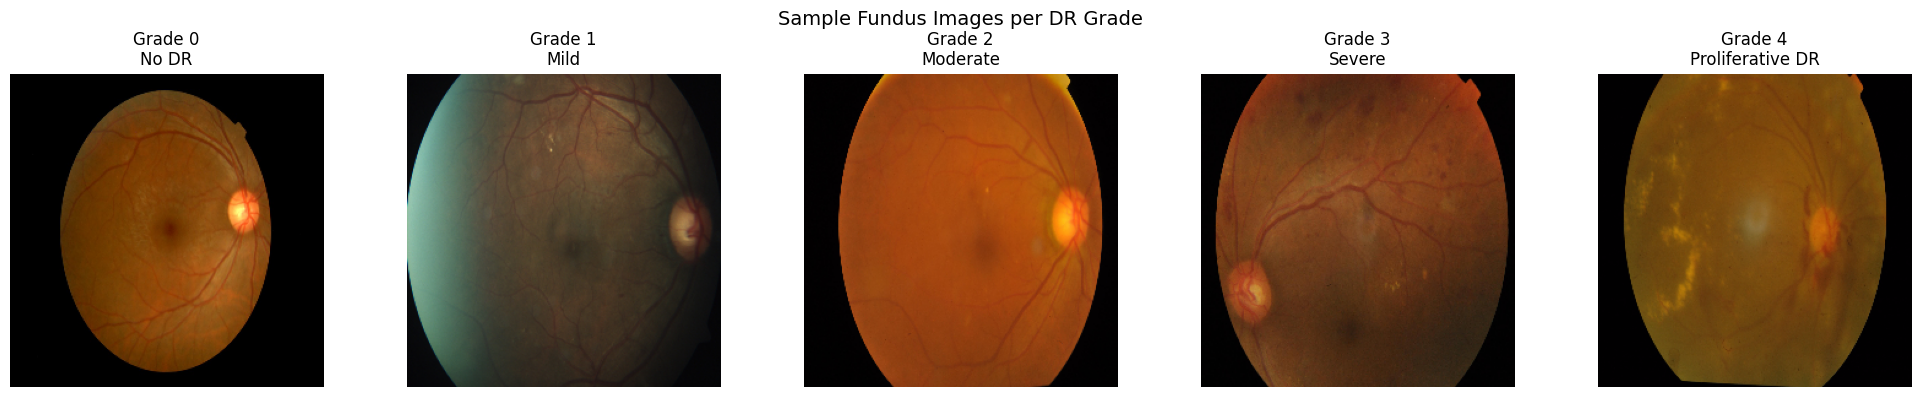

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for grade in range(5):
    row = df[df["diagnosis"] == grade].iloc[0]
    img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    axes[grade].imshow(img)
    axes[grade].set_title(f"Grade {grade}\n{GRADE_LABELS[grade]}")
    axes[grade].axis("off")
plt.suptitle("Sample Fundus Images per DR Grade", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── CELL 8: Config ──────────────────────────────────────────
IMG_SIZE     = 512
N_SEGMENTS   = 300   # ← was 150 — more superpixels = smaller regions = lesions get their own node
COMPACTNESS  = 10    # ← was 15 — lower = more shape-adaptive (better for irregular lesions)
SIGMA        = 1
K_NEIGHBOURS = 8
HIDDEN_DIM   = 128
NUM_LAYERS   = 3     # ← was 2
NUM_HEADS    = 4
DROPOUT      = 0.3   # ← was 0.5
EPOCHS       = 100   # ← was 80
LR           = 3e-4  # ← was 5e-4

print("✅ Config ready")
print(f"   IMG_SIZE={IMG_SIZE}, N_SEGMENTS={N_SEGMENTS}, K={K_NEIGHBOURS}")
print(f"   Hidden={HIDDEN_DIM}, Layers={NUM_LAYERS}, Heads={NUM_HEADS}")

✅ Config ready
   IMG_SIZE=512, N_SEGMENTS=300, K=8
   Hidden=128, Layers=3, Heads=4


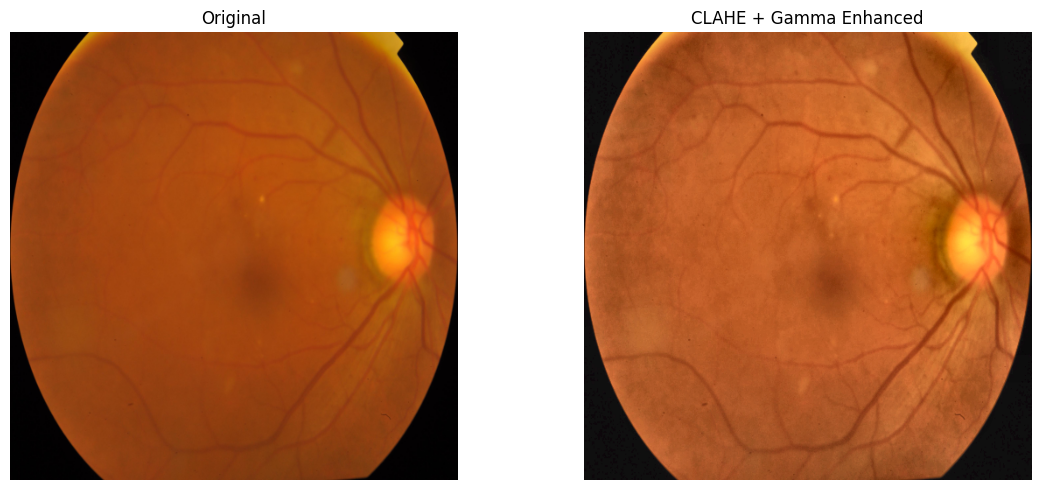

✅ Enhancement function ready


In [ ]:
def enhance_fundus_clahe(image_rgb, clip_limit=2.0, tile_grid=(8, 8), gamma=1.2):
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    L_clahe = clahe.apply(L)
    L_float   = L_clahe.astype(np.float32) / 255.0
    L_gamma   = np.power(L_float, 1.0 / gamma)
    L_out     = (L_gamma * 255).clip(0, 255).astype(np.uint8)
    lab_out   = cv2.merge([L_out, A, B])
    enhanced  = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)
    return enhanced


def load_and_enhance(image_path, target_size=512):
    img_bgr = cv2.imread(str(image_path))
    image   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    try:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
        coords   = cv2.findNonZero(mask)
        x, y, w, h = cv2.boundingRect(coords)
        image    = image[y:y+h, x:x+w]
    except Exception:
        pass
    image   = cv2.resize(image, (target_size, target_size), interpolation=cv2.INTER_AREA)
    enhanced = enhance_fundus_clahe(image)
    return enhanced, image


sample_path = df[df["diagnosis"] == 2].iloc[0]["img_path"]
enhanced_demo, original_demo = load_and_enhance(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original_demo); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(enhanced_demo); axes[1].set_title("CLAHE + Gamma Enhanced"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print("✅ Enhancement function ready")

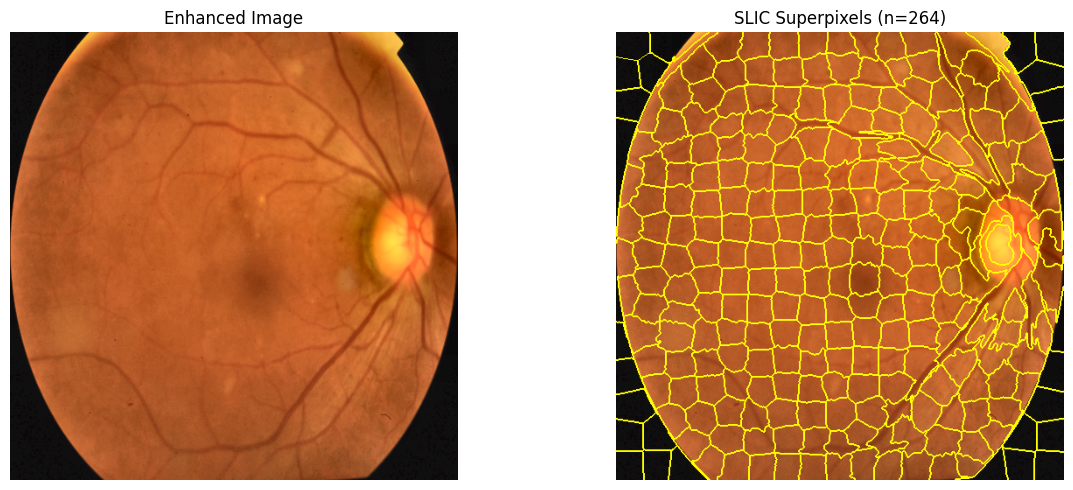

✅ Superpixels: 264


In [ ]:
def generate_superpixels(image_rgb, n_segments=150, compactness=15, sigma=1):
    img_lab  = rgb2lab(image_rgb.astype(np.float32) / 255.0)
    segments = slic(
        img_lab,
        n_segments  = n_segments,
        compactness = compactness,
        sigma       = sigma,
        start_label = 0,
        channel_axis= -1
    )
    n_sp = int(segments.max() + 1)
    return segments, n_sp


segs_demo, n_sp_demo = generate_superpixels(enhanced_demo, N_SEGMENTS, COMPACTNESS)
boundaries = mark_boundaries(enhanced_demo.astype(np.float32) / 255.0, segs_demo)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(enhanced_demo); axes[0].set_title("Enhanced Image"); axes[0].axis("off")
axes[1].imshow(boundaries);    axes[1].set_title(f"SLIC Superpixels (n={n_sp_demo})"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print(f"✅ Superpixels: {n_sp_demo}")

In [ ]:
def compute_anomaly_maps(image_original):
    img_f  = image_original.astype(np.float32) / 255.0
    gray   = cv2.cvtColor(image_original, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    g_ch   = img_f[:, :, 1]
    r_ch   = img_f[:, :, 0]

    retina_mask = (gray > 0.08).astype(np.float32)
    g_uint8 = (g_ch * 255).clip(0, 255).astype(np.uint8)

    vessel_combined = np.zeros_like(g_ch, dtype=np.float32)
    for ksize in [15, 25, 35]:
        kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        closed  = cv2.morphologyEx(g_uint8, cv2.MORPH_CLOSE, kernel)
        bth     = np.clip((closed.astype(np.float32) - g_uint8) / 255.0, 0, 1)
        vessel_combined = np.maximum(vessel_combined, bth)

    vessel_binary = (vessel_combined > 0.03).astype(np.float32)
    vessel_binary = cv2.dilate(
        vessel_binary,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)),
        iterations=1
    )
    non_vessel = 1.0 - vessel_binary

    ha_raw = np.zeros_like(g_ch, dtype=np.float32)
    for ksize in [9, 15, 21]:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        closed = cv2.morphologyEx(g_uint8, cv2.MORPH_CLOSE, kernel)
        bth    = np.clip((closed.astype(np.float32) - g_uint8) / 255.0, 0, 1)
        ha_raw = np.maximum(ha_raw, bth)

    redness  = np.clip((r_ch - g_ch) / (g_ch + 0.05), 0, 1)
    ha_raw   = ha_raw * (1.0 + redness * 0.8)
    ha_raw  *= non_vessel

    ex_raw = np.zeros_like(g_ch, dtype=np.float32)
    for ksize in [9, 15, 21]:
        kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        opened  = cv2.morphologyEx(g_uint8, cv2.MORPH_OPEN, kernel)
        wth     = np.clip((g_uint8.astype(np.float32) - opened.astype(np.float32)) / 255.0, 0, 1)
        ex_raw  = np.maximum(ex_raw, wth)

    ex_raw *= non_vessel

    def normalize(m, mask):
        vals = m[mask > 0.5]
        if len(vals) == 0:
            return m
        p99 = np.percentile(vals, 99)
        if p99 < 1e-6:
            return m
        return np.clip(m / p99, 0, 1) * mask

    ha_map = normalize(ha_raw, retina_mask)
    ex_map = normalize(ex_raw, retina_mask)

    return ex_map.astype(np.float32), ha_map.astype(np.float32)


print("✅ compute_anomaly_maps ready")

✅ compute_anomaly_maps ready


In [ ]:
def extract_superpixel_features(image_original, image_enhanced, segments, n_sp):
    H, W     = image_original.shape[:2]
    orig_f   = image_original.astype(np.float32) / 255.0
    enh_f    = image_enhanced.astype(np.float32) / 255.0
    orig_lab = rgb2lab(orig_f)
    orig_hsv = cv2.cvtColor(image_original, cv2.COLOR_RGB2HSV).astype(np.float32) / 255.0
    gray     = cv2.cvtColor(image_original, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    ex_map, ha_map = compute_anomaly_maps(image_original)

    features  = []
    centroids = []

    gray_uint8 = (gray * 255).clip(0, 255).astype(np.uint8)
    lbp = local_binary_pattern(gray_uint8, P=8, R=1, method='uniform').astype(np.float32)

    for sp_id in range(n_sp):
        mask = (segments == sp_id)
        if mask.sum() == 0:
            features.append(np.zeros(44, dtype=np.float32))
            centroids.append((H // 2, W // 2))
            continue

        rows, cols  = np.where(mask)
        cr          = rows.mean() / H
        cc          = cols.mean() / W
        dist_center = np.sqrt((cr - 0.5)**2 + (cc - 0.5)**2)
        norm_area   = mask.sum() / (H * W)
        border      = float(rows.min() < 8 or rows.max() > H - 8 or
                            cols.min() < 8 or cols.max() > W - 8)

        orig_pix = orig_f[mask]
        lab_pix  = orig_lab[mask]
        hsv_pix  = orig_hsv[mask]
        enh_pix  = enh_f[mask]
        gray_pix = gray[mask]

        mean_rgb_o = orig_pix.mean(axis=0)
        std_rgb_o  = orig_pix.std(axis=0)
        mean_lab   = lab_pix.mean(axis=0)
        rg_ratio   = mean_rgb_o[0] / (mean_rgb_o[1] + 1e-6)

        mean_rgb_e = enh_pix.mean(axis=0)
        std_rgb_e  = enh_pix.std(axis=0)

        mean_V = hsv_pix[:, 2].mean()
        mean_S = hsv_pix[:, 1].mean()

        ex_score = float(ex_map[mask].mean())
        ha_score = float(ha_map[mask].mean())

        lbp_pix  = lbp[mask]
        lbp_mean = float(lbp_pix.mean())
        lbp_std  = float(lbp_pix.std())

        r0, r1 = rows.min(), rows.max() + 1
        c0, c1 = cols.min(), cols.max() + 1
        patch_gray    = gray_uint8[r0:r1, c0:c1]
        patch_mask_2d = mask[r0:r1, c0:c1]
        patch_masked  = patch_gray * patch_mask_2d
        GLCM_PROPS = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]
        if patch_masked.shape[0] >= 2 and patch_masked.shape[1] >= 2:
            glcm = graycomatrix(patch_masked, distances=[1], angles=[0],
                                levels=256, symmetric=True, normed=True)
            glcm_feats = np.array([graycoprops(glcm, p)[0, 0] for p in GLCM_PROPS])
        else:
            glcm_feats = np.zeros(5, dtype=np.float32)

        gray_pix_clipped = np.clip(gray_pix, 0, 1)
        hist, _ = np.histogram(gray_pix_clipped, bins=32, range=(0, 1), density=True)
        hist = hist + 1e-10
        shannon_entropy = float(-(hist * np.log2(hist)).sum())

        patch_mask_shape = mask[r0:r1, c0:c1].astype(np.uint8)
        props = measure.regionprops(patch_mask_shape)
        if props:
            p = props[0]
            eccentricity = float(p.eccentricity)
            solidity     = float(p.solidity)
            extent       = float(p.extent)
        else:
            eccentricity, solidity, extent = 0.0, 0.0, 0.0

        feat = np.array([
            *mean_rgb_o, *std_rgb_o, *mean_lab,
            rg_ratio, mean_lab[2], mean_lab[0],
            *mean_rgb_e, *std_rgb_e,
            mean_V, mean_S, ex_score, ha_score,
            cr, cc, dist_center, norm_area, border,
            orig_pix[:, 1].min(), gray_pix.mean(), gray_pix.std(),
            lbp_mean, lbp_std,
            ex_score * ha_score,
            float(gray_pix.mean() < 0.25),
            float(rg_ratio > 1.1),
            *glcm_feats,
            shannon_entropy, eccentricity, solidity, extent,
        ], dtype=np.float32)

        features.append(feat)
        centroids.append((rows.mean(), cols.mean()))

    return np.array(features, dtype=np.float32), centroids


sample_path = df[df["diagnosis"] == 2].iloc[0]["img_path"]
enhanced_demo, original_demo = load_and_enhance(sample_path)
segs_demo, n_sp_demo = generate_superpixels(enhanced_demo, N_SEGMENTS, COMPACTNESS, SIGMA)
feats_demo, cents_demo = extract_superpixel_features(
    original_demo, enhanced_demo, segs_demo, n_sp_demo
)
print(f"✅ Feature matrix: {feats_demo.shape}  ({n_sp_demo} nodes × 44 features)")

✅ Feature matrix: (264, 44)  (264 nodes × 44 features)


In [ ]:
def build_knn_graph(features, centroids, k=8):
    n = len(centroids)
    if n < 2:
        x = torch.zeros(1, features.shape[1])
        return Data(x=x, edge_index=torch.zeros(2, 0, dtype=torch.long))

    coords   = np.array(centroids, dtype=np.float32)
    k_actual = min(k + 1, n)

    nbrs = NearestNeighbors(n_neighbors=k_actual, algorithm="ball_tree")
    nbrs.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    src, dst, wts = [], [], []
    for i in range(n):
        for j in range(1, k_actual):
            src.append(i)
            dst.append(int(indices[i, j]))
            wts.append(float(distances[i, j]))

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr  = torch.tensor(wts, dtype=torch.float32).unsqueeze(1)

    x    = torch.tensor(features, dtype=torch.float32)
    mean = x.mean(dim=0, keepdim=True)
    std  = x.std(dim=0, keepdim=True).clamp(min=1e-8)
    x    = (x - mean) / std

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


graph_demo = build_knn_graph(feats_demo, cents_demo, k=K_NEIGHBOURS)
print(f"✅ Graph: {graph_demo.num_nodes} nodes, {graph_demo.num_edges} edges")
print(f"   Node feature dim : {graph_demo.x.shape[1]}")
print(f"   Edge feature dim : {graph_demo.edge_attr.shape[1]}")

✅ Graph: 264 nodes, 2112 edges
   Node feature dim : 44
   Edge feature dim : 1


In [ ]:
# ── CELL 15: LesionGAT model ────────────────────────────────
import copy

class LesionGAT(nn.Module):
    def __init__(self, in_channels, hidden=128, n_classes=2,
                 n_layers=3, heads=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout

        self.proj = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.LayerNorm(hidden),
            nn.ELU(),
            nn.Dropout(dropout)
        )

        self.convs    = nn.ModuleList()
        self.norms    = nn.ModuleList()
        self.proj_res = nn.ModuleList()

        for i in range(n_layers):
            in_ch = hidden * heads if i > 0 else hidden
            self.convs.append(
                GATConv(in_ch, hidden, heads=heads, dropout=dropout, concat=True)
            )
            self.norms.append(nn.LayerNorm(hidden * heads))
            self.proj_res.append(
                nn.Linear(in_ch, hidden * heads, bias=False)
                if in_ch != hidden * heads else nn.Identity()
            )

        final_dim = hidden * heads

        self.clf = nn.Sequential(
            nn.Linear(final_dim, final_dim // 2),
            nn.LayerNorm(final_dim // 2),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(final_dim // 2, n_classes)
        )

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        x = self.proj(x)
        for conv, norm, proj_r in zip(self.convs, self.norms, self.proj_res):
            residual = proj_r(x)
            h = conv(x, edge_index)
            h = norm(h)
            h = F.elu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = h + residual
        return self.clf(x)


# Quick shape test
_model_test = LesionGAT(in_channels=44, hidden=HIDDEN_DIM,
                         n_layers=NUM_LAYERS, heads=NUM_HEADS, dropout=DROPOUT).to(DEVICE)
_g   = graph_demo.to(DEVICE)
_out = _model_test(_g.x, _g.edge_index, _g.edge_attr)
print(f"✅ Model output shape: {_out.shape}")
del _model_test, _g, _out

✅ Model output shape: torch.Size([264, 2])


In [ ]:
from pathlib import Path
import re

LESION_TYPES = ["MA", "HE", "EX", "SE"]

def find_files_by_ext(base, ext):
    return sorted(Path(base).rglob(f"*{ext}"))

tif_files = find_files_by_ext(MASK_TRAIN_DIR, ".tif")
jpg_files = find_files_by_ext(IMG_TRAIN_DIR,  ".jpg")

print(f"Found {len(tif_files)} .tif mask files")
print(f"Found {len(jpg_files)} .jpg image files")

def is_training_file(path):
    path_str = str(path).lower()
    return "train" in path_str

jpg_train = [p for p in jpg_files if is_training_file(p)]
tif_train = [p for p in tif_files if is_training_file(p)]

eval_tifs = tif_train if tif_train else tif_files
eval_jpgs = jpg_train if jpg_train else jpg_files

img_lookup = {}
for p in eval_jpgs:
    img_lookup[p.stem] = str(p)

mask_lookup = {}
for tif in eval_tifs:
    stem = tif.stem
    m = re.match(r"(IDRiD_\d+)_([A-Z]+)$", stem, re.IGNORECASE)
    if not m:
        m = re.match(r"(\d+)_([A-Z]+)$", stem, re.IGNORECASE)
        if m:
            img_id = f"IDRiD_{int(m.group(1)):02d}"
            lesion = m.group(2).upper()
        else:
            continue
    else:
        img_id = m.group(1)
        lesion = m.group(2).upper()

    if lesion not in LESION_TYPES:
        continue
    if img_id not in mask_lookup:
        mask_lookup[img_id] = {}
    mask_lookup[img_id][lesion] = str(tif)

all_ids = set(mask_lookup.keys()) | set(img_lookup.keys())
records = []
for img_id in sorted(all_ids):
    rec = {"img_id": img_id, "img_path": img_lookup.get(img_id, None)}
    masks = mask_lookup.get(img_id, {})
    for lt in LESION_TYPES:
        rec[f"mask_{lt}"] = masks.get(lt, "")
    records.append(rec)

idrid_df = pd.DataFrame(records)
idrid_df["has_image"] = idrid_df["img_path"].apply(
    lambda p: p is not None and os.path.isfile(str(p))
)
idrid_df["has_any_mask"] = idrid_df.apply(
    lambda r: any(r[f"mask_{lt}"] != "" for lt in LESION_TYPES), axis=1
)

idrid_eval = idrid_df[idrid_df["has_image"] & idrid_df["has_any_mask"]].reset_index(drop=True)

print(f"Has BOTH image + mask: {len(idrid_eval)}")
for lt in LESION_TYPES:
    n = (idrid_eval[f"mask_{lt}"] != "").sum()
    print(f"   {lt}: {n} images")

Found 241 .tif mask files
Found 54 .jpg image files
Has BOTH image + mask: 54
   MA: 54 images
   HE: 53 images
   EX: 54 images
   SE: 26 images


In [ ]:
def load_gt_mask_safe(mask_path, eval_size=512):
    gt_raw = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if gt_raw is None:
        return np.zeros((eval_size, eval_size), dtype=np.uint8)
    gt_native_bin = (gt_raw > 0).astype(np.uint8) * 255
    gt_resized = cv2.resize(
        gt_native_bin.astype(np.float32),
        (eval_size, eval_size),
        interpolation=cv2.INTER_AREA
    )
    gt_bin = (gt_resized > 2).astype(np.uint8)
    return gt_bin


def compute_metrics(pred_bin, gt_bin):
    pred = pred_bin.astype(bool)
    gt   = gt_bin.astype(bool)

    TP = np.logical_and(pred,  gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()

    precision   = TP / (TP + FP + 1e-8)
    recall      = TP / (TP + FN + 1e-8)
    f1          = 2 * TP / (2 * TP + FP + FN + 1e-8)
    iou         = TP / (TP + FP + FN + 1e-8)
    dice        = 2 * TP / (2 * TP + FP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)

    return {
        "TP": int(TP), "FP": int(FP), "FN": int(FN), "TN": int(TN),
        "Precision":   round(float(precision),   4),
        "Recall":      round(float(recall),      4),
        "F1":          round(float(f1),          4),
        "IoU":         round(float(iou),         4),
        "Dice":        round(float(dice),        4),
        "Specificity": round(float(specificity), 4),
    }

print("✅ load_gt_mask_safe and compute_metrics ready")

✅ load_gt_mask_safe and compute_metrics ready


In [ ]:
# ── CELL 18: generate_labels_from_gt ────────────────────────
# KEY FIX: overlap_thresh lowered to 0.05 so tiny lesions get labelled

def generate_labels_from_gt(image_original, segments, n_sp,
                             mask_paths: dict, overlap_thresh=0.05):  # ← was 0.20
    H, W = image_original.shape[:2]
    combined_mask = np.zeros((H, W), dtype=np.uint8)

    stats = {}
    for lt, mp in mask_paths.items():
        if not mp or not os.path.isfile(str(mp)):
            stats[lt] = 0
            continue
        gt_raw = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        gt_bin_native = (gt_raw > 0).astype(np.uint8)
        gt_resized = cv2.resize(
            gt_bin_native.astype(np.float32), (W, H),
            interpolation=cv2.INTER_NEAREST
        ).astype(np.uint8)
        stats[lt] = int(gt_resized.sum())
        combined_mask = np.maximum(combined_mask, gt_resized)

    labels = torch.zeros(n_sp, dtype=torch.long)

    for sp_id in range(n_sp):
        m = (segments == sp_id)
        if m.sum() == 0:
            continue
        overlap = float(combined_mask[m].sum()) / float(m.sum())
        if overlap >= overlap_thresh:
            labels[sp_id] = 1

    n_lesion = int((labels == 1).sum())
    n_bg     = int((labels == 0).sum())
    print(f"   GT labels → Lesion: {n_lesion:>4} | BG: {n_bg:>4} | Total: {n_sp}  "
          f"| Stats: { {k:v for k,v in stats.items() if v>0} }")
    return labels, stats

print("✅ generate_labels_from_gt ready (overlap_thresh=0.05)")

✅ generate_labels_from_gt ready (overlap_thresh=0.05)


In [ ]:
# ── CELL 19: train_shared_gat with cross-validation ─────────

from sklearn.model_selection import KFold

def train_shared_gat(graphs, device=DEVICE, epochs=100, n_folds=5):
    """
    5-fold cross-validation.
    Returns the best model across all folds (highest val Dice).
    """
    kf  = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    idx = list(range(len(graphs)))

    fold_results       = []
    best_overall_model = None
    best_overall_dice  = 0.0

    for fold, (train_idx, val_idx) in enumerate(kf.split(idx)):
        print(f"\n{'='*55}")
        print(f"FOLD {fold+1}/{n_folds}  "
              f"train={len(train_idx)}  val={len(val_idx)}")
        print('='*55)

        train_graphs = [graphs[i] for i in train_idx]
        val_graphs   = [graphs[i] for i in val_idx]

        in_ch = graphs[0].x.shape[1]
        model = LesionGAT(in_ch, HIDDEN_DIM, 2,
                          NUM_LAYERS, NUM_HEADS, DROPOUT).to(device)

        opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=LR, epochs=epochs,
            steps_per_epoch=max(len(train_graphs), 1)
        )

        best_val_dice = 0.0
        best_state    = None
        patience_cnt  = 0
        PATIENCE      = 20
        MIN_EPOCHS    = 40

        for ep in range(epochs):
            model.train()
            ep_loss = 0.0

            perm = torch.randperm(len(train_graphs)).tolist()
            for i in perm:
                g      = train_graphs[i].to(device)
                labels = g.y.to(device)
                mask   = g.train_mask.to(device)
                if mask.sum() < 3:
                    continue

                n_bg  = (labels[mask] == 0).sum().item()
                n_les = (labels[mask] == 1).sum().item()
                # Cap at 30 — strong enough without exploding gradients
                w_les = float(np.clip(n_bg / (n_les + 1e-6), 3.0, 30.0))
                w     = torch.tensor([1.0, w_les], device=device)

                opt.zero_grad()
                logits = model(g.x, g.edge_index, g.edge_attr)
                probs  = F.softmax(logits[mask], dim=1)
                tgts   = labels[mask]
                p_t    = probs[torch.arange(len(tgts)), tgts]
                focal  = (1 - p_t) ** 2.5   # ← gamma 2.5, harder focus on misclassified
                ce     = F.cross_entropy(logits[mask], tgts, weight=w, reduction='none')
                loss   = (focal * ce).mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                sched.step()
                ep_loss += loss.item()

            # Validation Dice
            model.eval()
            val_dices = []
            with torch.no_grad():
                for g in val_graphs:
                    gg        = g.to(device)
                    logits    = model(gg.x, gg.edge_index, gg.edge_attr)
                    probs_np  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
                    labels_np = g.y.cpu().numpy()
                    preds     = (probs_np > 0.3).astype(np.int64)
                    TP = ((preds==1)&(labels_np==1)).sum()
                    FP = ((preds==1)&(labels_np==0)).sum()
                    FN = ((preds==0)&(labels_np==1)).sum()
                    dice = 2*TP / (2*TP + FP + FN + 1e-8)
                    val_dices.append(dice)

            mean_dice = float(np.mean(val_dices)) if val_dices else 0.0

            if ep % 20 == 0:
                print(f"  Epoch {ep:3d} | Loss: {ep_loss/max(len(train_graphs),1):.4f} "
                      f"| Val Dice: {mean_dice:.4f}")

            if mean_dice > best_val_dice + 1e-4:
                best_val_dice = mean_dice
                best_state    = copy.deepcopy(model.state_dict())
                patience_cnt  = 0
            else:
                patience_cnt += 1
            if patience_cnt >= PATIENCE and ep >= MIN_EPOCHS:
                print(f"  Early stop epoch {ep}  best_dice={best_val_dice:.4f}")
                break

        fold_results.append({"fold": fold+1, "best_val_dice": best_val_dice})
        print(f"\n  ✅ Fold {fold+1} best val Dice = {best_val_dice:.4f}")

        if best_val_dice > best_overall_dice and best_state is not None:
            best_overall_dice  = best_val_dice
            best_overall_model = LesionGAT(
                in_ch, HIDDEN_DIM, 2, NUM_LAYERS, NUM_HEADS, DROPOUT
            ).to(device)
            best_overall_model.load_state_dict(best_state)

    print("\n" + "="*55)
    print("CROSS-VALIDATION SUMMARY")
    print("="*55)
    dices = [r['best_val_dice'] for r in fold_results]
    for r in fold_results:
        print(f"  Fold {r['fold']}: Val Dice = {r['best_val_dice']:.4f}")
    print(f"\n  Mean Dice = {np.mean(dices):.4f} ± {np.std(dices):.4f}")
    print(f"  Best Dice = {max(dices):.4f}")

    # Fallback: if all folds gave 0 (extreme imbalance), return last model
    if best_overall_model is None:
        print("  ⚠️  All folds had Dice=0, returning last trained model")
        best_overall_model = model

    return best_overall_model, fold_results

print("✅ train_shared_gat (cross-val) ready")

✅ train_shared_gat (cross-val) ready


Building GT-supervised dataset (overlap_thresh=0.05)...


  2%|▏         | 1/54 [00:09<08:14,  9.34s/it]

   GT labels → Lesion:   23 | BG:  246 | Total: 269  | Stats: {'MA': 154, 'HE': 753, 'EX': 2434}


  4%|▎         | 2/54 [00:12<04:54,  5.67s/it]

   GT labels → Lesion:   22 | BG:  246 | Total: 268  | Stats: {'MA': 200, 'HE': 377, 'EX': 2903}


...

 98%|█████████▊| 53/54 [03:11<00:03,  3.66s/it]

   GT labels → Lesion:   17 | BG:  247 | Total: 264  | Stats: {'MA': 569, 'HE': 1947, 'EX': 239, 'SE': 187}


100%|██████████| 54/54 [03:15<00:00,  3.63s/it]

   GT labels → Lesion:   15 | BG:  239 | Total: 254  | Stats: {'MA': 521, 'HE': 831, 'EX': 201, 'SE': 674}

✅ Built 54 graphs (0 skipped)
   Total lesion SPs: 1449  BG SPs: 12491  Ratio: 8.6:1
   ✅ Class balance acceptable for training
Total graphs: 54
Training GAT with 5-fold cross-validation...

FOLD 1/5  train=43  val=11


  Epoch   0 | Loss: 0.3113 | Val Dice: 0.2503
  Epoch  20 | Loss: 0.1530 | Val Dice: 0.2919
  Epoch  40 | Loss: 0.1265 | Val Dice: 0.2952
  Early stop epoch 58  best_dice=0.3459

  ✅ Fold 1 best val Dice = 0.3459

FOLD 2/5  train=43  val=11
  Epoch   0 | Loss: 0.3438 | Val Dice: 0.2607
  Epoch  20 | Loss: 0.1507 | Val Dice: 0.2730
  Epoch  40 | Loss: 0.1226 | Val Dice: 0.3093
  Early stop epoch 54  best_dice=0.3357

  ✅ Fold 2 best val Dice = 0.3357

FOLD 3/5  train=43  val=11
  Epoch   0 | Loss: 0.2890 | Val Dice: 0.2571
  Epoch  20 | Loss: 0.1507 | Val Dice: 0.2646
  Epoch  40 | Loss: 0.1258 | Val Dice: 0.2854
  Epoch  60 | Loss: 0.1077 | Val Dice: 0.2731
  Early stop epoch 60  best_dice=0.2854

  ✅ Fold 3 best val Dice = 0.2854

FOLD 4/5  train=43  val=11
  Epoch   0 | Loss: 0.3044 | Val Dice: 0.1586
  Epoch  20 | Loss: 0.1492 | Val Dice: 0.1618
  Epoch  40 | Loss: 0.1280 | Val Dice: 0.1756
  Early stop epoch 56  best_dice=0.2016

  ✅ Fold 4 best val Dice = 0.2016

FOLD 5/5  train=4

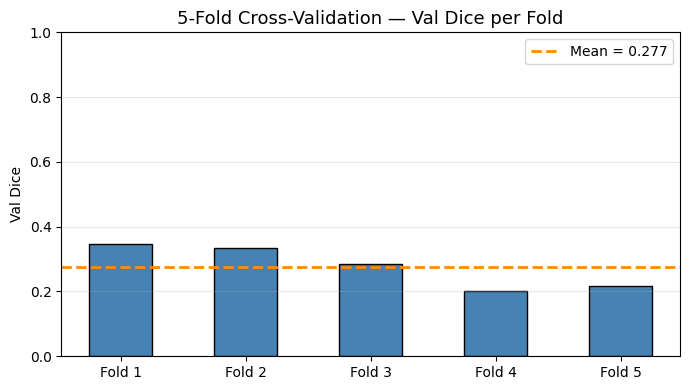

In [ ]:
# ── CELL 20: build_gt_dataset ────────────────────────────────

def build_gt_dataset(idrid_eval_df, overlap_thresh=0.05):  # ← was 0.20
    graphs  = []
    skipped = 0

    for _, row in tqdm(idrid_eval_df.iterrows(), total=len(idrid_eval_df)):
        img_path = row["img_path"]
        if not img_path or not os.path.isfile(str(img_path)):
            skipped += 1
            continue
        try:
            enh, orig    = load_and_enhance(img_path, IMG_SIZE)
            segs, n_sp   = generate_superpixels(enh, N_SEGMENTS, COMPACTNESS, SIGMA)
            feats, cents = extract_superpixel_features(orig, enh, segs, n_sp)
            graph_cpu    = build_knn_graph(feats, cents, K_NEIGHBOURS)

            mask_paths = {lt: row.get(f"mask_{lt}", "") for lt in LESION_TYPES}
            labels, _  = generate_labels_from_gt(
                orig, segs, n_sp, mask_paths,
                overlap_thresh=overlap_thresh
            )

            graph_cpu.y          = labels
            graph_cpu.train_mask = torch.ones(n_sp, dtype=torch.bool)
            graph_cpu.img_id     = row["img_id"]
            graphs.append(graph_cpu)

        except Exception as e:
            print(f"   ⚠️  Skipped {row.get('img_id','?')}: {e}")
            skipped += 1

    print(f"\n✅ Built {len(graphs)} graphs ({skipped} skipped)")

    # Print class balance summary
    total_les, total_bg = 0, 0
    for g in graphs:
        total_les += (g.y == 1).sum().item()
        total_bg  += (g.y == 0).sum().item()
    print(f"   Total lesion SPs: {total_les}  BG SPs: {total_bg}  "
          f"Ratio: {total_bg/(total_les+1e-6):.1f}:1")
    if total_les == 0:
        print("   ⚠️  STILL ZERO LESIONS — check mask paths above")
    elif total_bg / (total_les + 1e-6) > 15:
        print("   ⚠️  Ratio still high — training will use strong class weights")
    else:
        print("   ✅ Class balance acceptable for training")

    return graphs


print("Building GT-supervised dataset (overlap_thresh=0.05)...")
gt_graphs = build_gt_dataset(idrid_eval, overlap_thresh=0.05)
print(f"Total graphs: {len(gt_graphs)}")

# ── CELL 21: Train ───────────────────────────────────────────

print("Training GAT with 5-fold cross-validation...")
gt_model, cv_results = train_shared_gat(gt_graphs, device=DEVICE, epochs=100)
gt_model.eval()

torch.save(gt_model.state_dict(), "/content/gt_gat_model.pt")
print("✅ Best model saved to /content/gt_gat_model.pt")

# Plot fold summary
dices = [r['best_val_dice'] for r in cv_results]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f"Fold {r['fold']}" for r in cv_results], dices,
       color="steelblue", edgecolor="black", width=0.5)
ax.axhline(np.mean(dices), color="darkorange", linestyle="--",
           lw=2, label=f"Mean = {np.mean(dices):.3f}")
ax.set_title("5-Fold Cross-Validation — Val Dice per Fold", fontsize=13)
ax.set_ylabel("Val Dice")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── CELL 22: Find optimal threshold ─────────────────────────

def find_best_threshold(model, graphs, device=DEVICE):
    """Sweep thresholds and pick the one with best Dice on all graphs."""
    thresholds = np.arange(0.10, 0.91, 0.05)
    model.eval()

    all_probs, all_labels = [], []
    with torch.no_grad():
        for g in graphs:
            gg    = g.to(device)
            logits = model(gg.x, gg.edge_index, gg.edge_attr)
            probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs.append(probs)
            all_labels.append(g.y.cpu().numpy())

    all_probs_flat  = np.concatenate(all_probs)
    all_labels_flat = np.concatenate(all_labels)

    print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'Dice':>8}")
    print("-"*42)

    best_thresh, best_dice = 0.3, 0.0
    for t in thresholds:
        preds = (all_probs_flat > t).astype(np.int64)
        TP = ((preds==1)&(all_labels_flat==1)).sum()
        FP = ((preds==1)&(all_labels_flat==0)).sum()
        FN = ((preds==0)&(all_labels_flat==1)).sum()
        prec = TP / (TP + FP + 1e-8)
        rec  = TP / (TP + FN + 1e-8)
        dice = 2*TP / (2*TP + FP + FN + 1e-8)
        print(f"{t:>10.2f} {prec:>10.3f} {rec:>10.3f} {dice:>8.3f}")
        if dice > best_dice:
            best_dice, best_thresh = dice, t

    print(f"\n✅ Best threshold = {best_thresh:.2f}  Dice = {best_dice:.4f}")
    return float(best_thresh)


BEST_THRESH = find_best_threshold(gt_model, gt_graphs, DEVICE)
print(f"\nBEST_THRESH = {BEST_THRESH}")

 Threshold  Precision     Recall     Dice
------------------------------------------
      0.10      0.133      0.998    0.235
      0.15      0.147      0.998    0.256
      0.20      0.162      0.994    0.279
      0.25      0.182      0.982    0.307
      0.30      0.213      0.954    0.348
      0.35      0.264      0.903    0.408
      0.40      0.343      0.825    0.485
      0.45      0.442      0.733    0.551
      0.50      0.539      0.619    0.576
      0.55      0.628      0.509    0.562
      0.60      0.711      0.410    0.520
      0.65      0.774      0.316    0.449
      0.70      0.836      0.222    0.351
      0.75      0.904      0.155    0.265
      0.80      0.973      0.075    0.138
      0.85      1.000      0.029    0.056
      0.90      1.000      0.002    0.004

✅ Best threshold = 0.50  Dice = 0.5765

BEST_THRESH = 0.5000000000000001


In [ ]:
# ── CELL 23: evaluate_one_image ─────────────────────────────

def evaluate_one_image(row, model, threshold=None, device=DEVICE, verbose=True):
    # Use globally found best threshold, fallback to 0.3
    if threshold is None:
        threshold = BEST_THRESH if 'BEST_THRESH' in globals() else 0.3

    img_path = row["img_path"]
    if not img_path or not os.path.isfile(str(img_path)):
        print(f"  ⚠️ Image not found: {img_path}")
        return None

    enh, orig    = load_and_enhance(img_path, IMG_SIZE)
    segs, n_sp   = generate_superpixels(enh, N_SEGMENTS, COMPACTNESS, SIGMA)
    feats, cents = extract_superpixel_features(orig, enh, segs, n_sp)
    graph_cpu    = build_knn_graph(feats, cents, K_NEIGHBOURS)
    graph_gpu    = graph_cpu.to(device)

    model.eval()
    with torch.no_grad():
        logits = model(graph_gpu.x, graph_gpu.edge_index, graph_gpu.edge_attr)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

    if verbose:
        print(f"   Probs: min={probs.min():.4f}  max={probs.max():.4f}  "
              f"mean={probs.mean():.4f}  std={probs.std():.4f}")

    preds      = (probs > threshold).astype(np.uint8)
    pred_pixel = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    for sp_id in range(n_sp):
        if preds[sp_id] == 1:
            pred_pixel[segs == sp_id] = 1

    EVAL_SIZE    = 512
    pred_resized = cv2.resize(pred_pixel, (EVAL_SIZE, EVAL_SIZE),
                              interpolation=cv2.INTER_NEAREST)

    if verbose:
        print(f"   Threshold: {threshold:.2f} | Lesion SPs: {preds.sum()}/{n_sp} "
              f"({100*preds.sum()/max(n_sp,1):.1f}%)")

    results = {
        "img_id":      row["img_id"],
        "thresh":      threshold,
        "prob_max":    float(probs.max()),
        "n_lesion_sp": int(preds.sum()),
        "n_total_sp":  n_sp,
        "lesion_pct":  100.0 * preds.sum() / max(n_sp, 1),
    }

    for lt in LESION_TYPES:
        mask_path = row.get(f"mask_{lt}", "")
        if not mask_path or not os.path.isfile(str(mask_path)):
            results[lt] = None
            continue
        gt_bin = load_gt_mask_safe(str(mask_path), eval_size=EVAL_SIZE)
        if gt_bin.sum() == 0:
            results[lt] = None
            continue
        m = compute_metrics(pred_resized, gt_bin)
        results[lt] = m
        if verbose:
            print(f"   {lt}: Dice={m['Dice']:.3f}  IoU={m['IoU']:.3f}  "
                  f"Prec={m['Precision']:.3f}  Rec={m['Recall']:.3f}")

    results.update({"probs": probs, "preds": preds,
                    "pred_pixel": pred_resized, "orig": orig, "segs": segs})
    return results

print("✅ evaluate_one_image ready")

✅ evaluate_one_image ready


In [ ]:
# ── CELL 24: Run evaluation ──────────────────────────────────

print(f"Evaluating with threshold = {BEST_THRESH:.2f}\n")
gt_all_results = []
for _, row in tqdm(idrid_eval.iterrows(), total=len(idrid_eval)):
    print(f"\n── {row['img_id']} ──")
    res = evaluate_one_image(row, gt_model, threshold=BEST_THRESH,
                             device=DEVICE, verbose=True)
    if res is not None:
        gt_all_results.append(res)

print(f"\n✅ Evaluated {len(gt_all_results)} images")

# ── CELL 25: Metrics summary ─────────────────────────────────

metric_keys  = ["Precision", "Recall", "F1", "IoU", "Dice", "Specificity"]
flat_records = []
for res in gt_all_results:
    for lt in LESION_TYPES:
        m = res.get(lt)
        if m is None:
            continue
        rec = {"img_id": res["img_id"], "lesion": lt}
        rec.update({k: m[k] for k in metric_keys})
        flat_records.append(rec)

flat_df    = pd.DataFrame(flat_records)
per_lesion = flat_df.groupby("lesion")[metric_keys].mean().round(4)
overall    = flat_df[metric_keys].mean().round(4).rename("Overall")
summary    = pd.concat([per_lesion, overall.to_frame().T])

print("\n" + "="*65)
print(f"📊 IMPROVED MODEL — threshold={BEST_THRESH:.2f}")
print("="*65)
print(summary[["Precision","Recall","F1","IoU","Dice"]].to_string())
print("="*65)

Evaluating with threshold = 0.50



  0%|          | 0/54 [00:00<?, ?it/s]


── IDRiD_01 ──


  2%|▏         | 1/54 [00:06<05:37,  6.38s/it]

   Probs: min=0.0220  max=0.7811  mean=0.2481  std=0.1715
   Threshold: 0.50 | Lesion SPs: 19/269 (7.1%)
   MA: Dice=0.007  IoU=0.004  Prec=0.004  Rec=0.222
   HE: Dice=0.007  IoU=0.004  Prec=0.004  Rec=0.064
   EX: Dice=0.217  IoU=0.122  Prec=0.132  Rec=0.622

── IDRiD_02 ──


...

   SE: Dice=0.000  IoU=0.000  Prec=0.000  Rec=0.000

── IDRiD_53 ──
   Probs: min=0.0221  max=0.5334  mean=0.1970  std=0.1317
   Threshold: 0.50 | Lesion SPs: 2/264 (0.8%)
   MA: Dice=0.068  IoU=0.035  Prec=0.060  Rec=0.076
   HE: Dice=0.071  IoU=0.037  Prec=0.102  Rec=0.055
   EX: Dice=0.011  IoU=0.005  Prec=0.007  Rec=0.021


 98%|█████████▊| 53/54 [03:04<00:03,  3.34s/it]

   SE: Dice=0.000  IoU=0.000  Prec=0.000  Rec=0.000

── IDRiD_54 ──
   Probs: min=0.0220  max=0.6486  mean=0.2398  std=0.1622
   Threshold: 0.50 | Lesion SPs: 11/254 (4.3%)
   MA: Dice=0.029  IoU=0.015  Prec=0.016  Rec=0.172
   HE: Dice=0.059  IoU=0.030  Prec=0.033  Rec=0.279


100%|██████████| 54/54 [03:07<00:00,  3.48s/it]

   EX: Dice=0.034  IoU=0.017  Prec=0.017  Rec=0.516
   SE: Dice=0.002  IoU=0.001  Prec=0.001  Rec=0.015

✅ Evaluated 54 images

📊 IMPROVED MODEL — threshold=0.50
         Precision  Recall      F1     IoU    Dice
EX          0.0600  0.5943  0.1058  0.0586  0.1058
HE          0.0355  0.3661  0.0586  0.0313  0.0586
MA          0.0055  0.2833  0.0098  0.0049  0.0098
SE          0.0207  0.4234  0.0386  0.0201  0.0386
Overall     0.0319  0.4160  0.0553  0.0300  0.0553


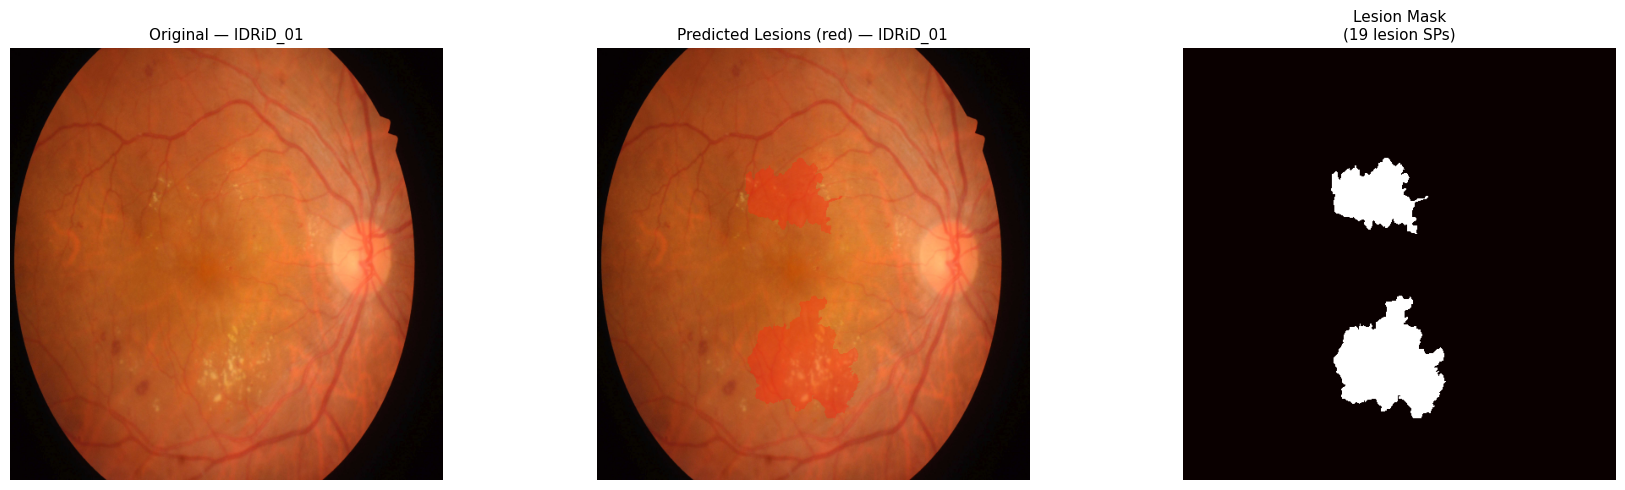

   IDRiD_01 — lesion SPs: 19


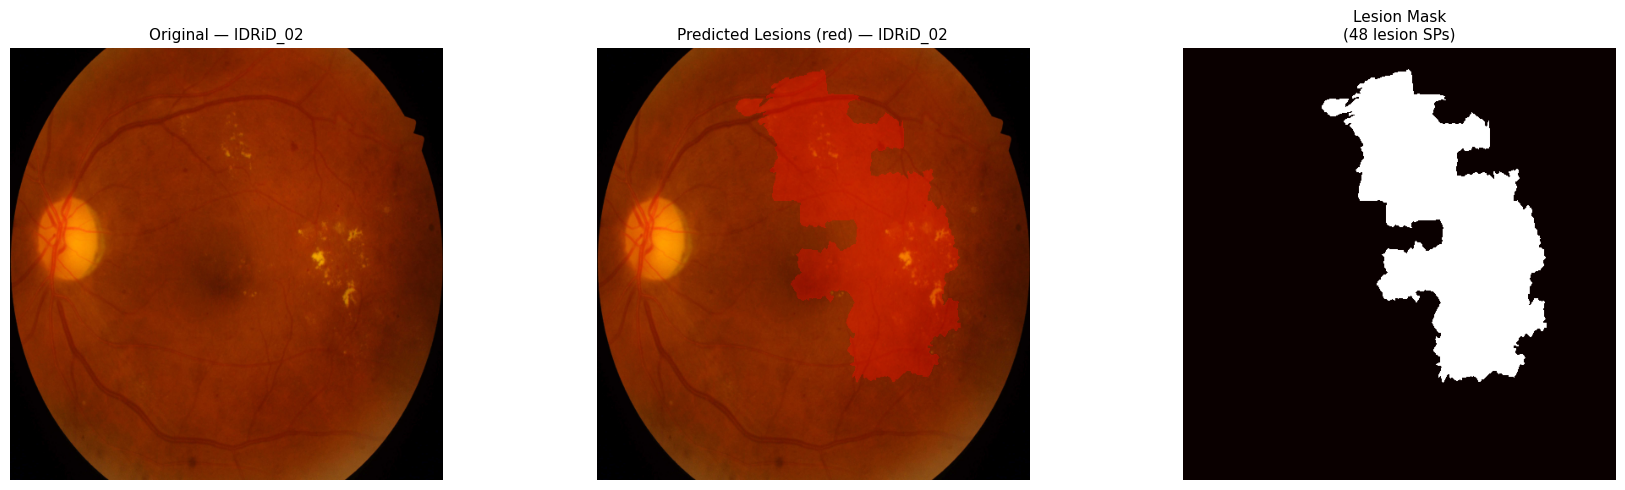

   IDRiD_02 — lesion SPs: 48


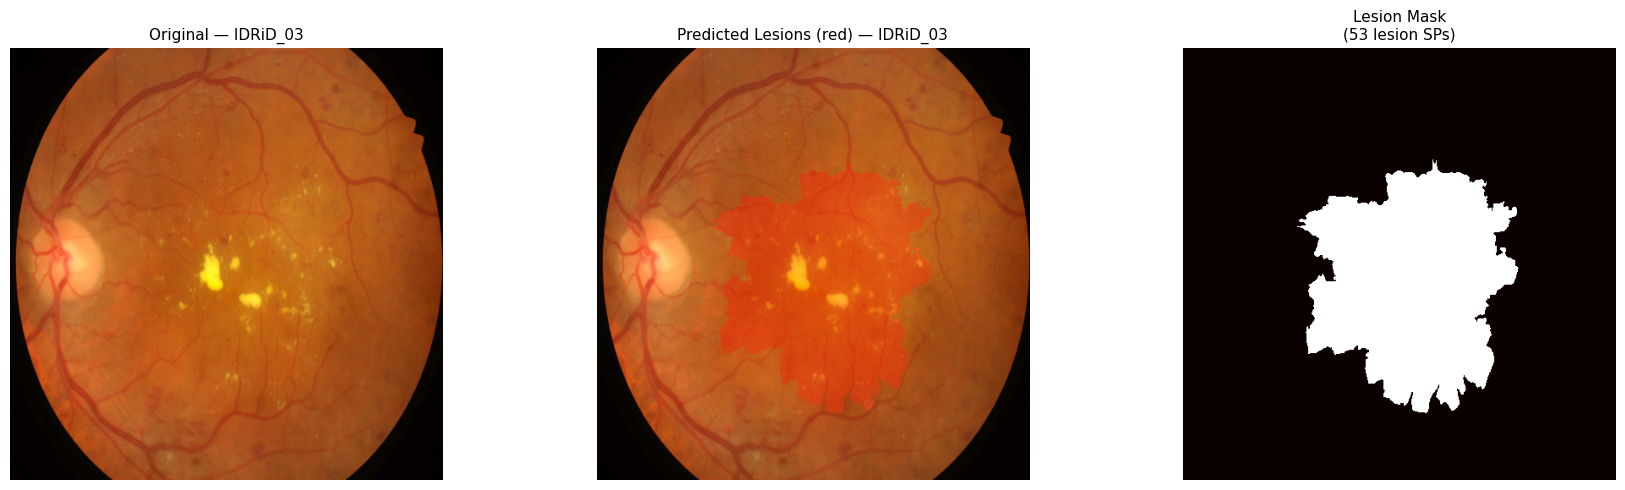

   IDRiD_03 — lesion SPs: 53


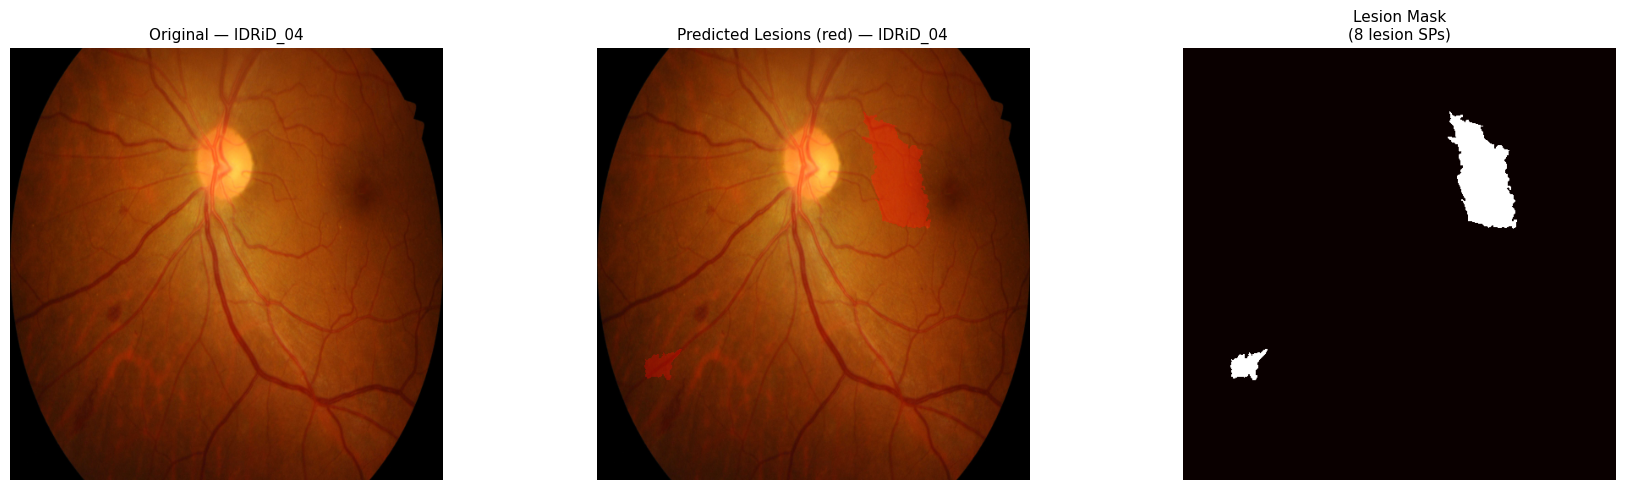

   IDRiD_04 — lesion SPs: 8


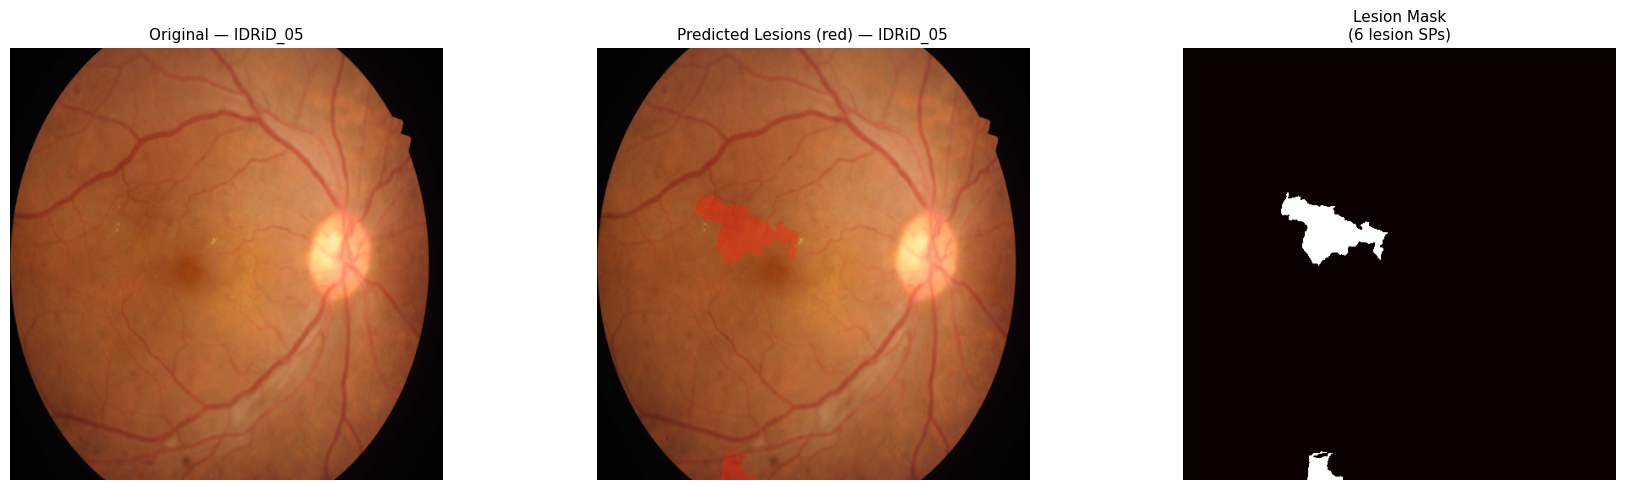

   IDRiD_05 — lesion SPs: 6


In [ ]:
# Cell NEW — Visualise detected lesions on image

def visualize_lesion_overlay(result, save=False):
    """Overlay predicted lesion superpixels on the original fundus image."""
    orig      = result["orig"]           # H×W×3 uint8
    pred_px   = result["pred_pixel"]     # 512×512 binary mask
    img_id    = result["img_id"]

    # Resize orig to match pred_pixel if needed
    orig_resized = cv2.resize(orig, (512, 512))

    # Create overlay: red tint on lesion pixels
    overlay = orig_resized.copy().astype(np.float32)
    lesion_mask = pred_px.astype(bool)
    overlay[lesion_mask, 0] = np.clip(overlay[lesion_mask, 0] * 0.5 + 180, 0, 255)
    overlay[lesion_mask, 1] = np.clip(overlay[lesion_mask, 1] * 0.4, 0, 255)
    overlay[lesion_mask, 2] = np.clip(overlay[lesion_mask, 2] * 0.4, 0, 255)
    overlay = overlay.astype(np.uint8)

    # Blend: 60% original + 40% overlay
    blended = cv2.addWeighted(orig_resized, 0.6, overlay, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(orig_resized)
    axes[0].set_title(f"Original — {img_id}", fontsize=11)
    axes[0].axis("off")

    axes[1].imshow(blended)
    axes[1].set_title(f"Predicted Lesions (red) — {img_id}", fontsize=11)
    axes[1].axis("off")

    axes[2].imshow(pred_px, cmap="hot")
    axes[2].set_title(f"Lesion Mask\n({result['n_lesion_sp']} lesion SPs)", fontsize=11)
    axes[2].axis("off")

    plt.tight_layout()
    if save:
        plt.savefig(f"/content/{img_id}_lesion_overlay.png", dpi=150, bbox_inches='tight')
    plt.show()


# Show overlays for first 5 evaluated images
for res in gt_all_results[:5]:
    visualize_lesion_overlay(res, save=True)
    print(f"   {res['img_id']} — lesion SPs: {res['n_lesion_sp']}")

In [ ]:
# ── CELL 27: Grade-wise evaluation ──────────────────────────

from scipy.stats import spearmanr

def evaluate_gradewise(df_aptos, model, device=DEVICE, n_per_grade=10):
    results = []
    for grade in range(5):
        grade_df    = df_aptos[df_aptos["diagnosis"] == grade]
        sample      = grade_df.iloc[:n_per_grade]
        lesion_pcts = []
        n_lesion_list = []

        for _, row in sample.iterrows():
            try:
                enh, orig    = load_and_enhance(row["img_path"], IMG_SIZE)
                segs, n_sp   = generate_superpixels(enh, N_SEGMENTS, COMPACTNESS, SIGMA)
                feats, cents = extract_superpixel_features(orig, enh, segs, n_sp)
                graph_cpu    = build_knn_graph(feats, cents, K_NEIGHBOURS)
                graph_gpu    = graph_cpu.to(device)

                model.eval()
                with torch.no_grad():
                    logits = model(graph_gpu.x, graph_gpu.edge_index, graph_gpu.edge_attr)
                    probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

                # Use BEST_THRESH here too (not Otsu)
                thresh = BEST_THRESH if 'BEST_THRESH' in globals() else 0.3
                preds  = (probs > thresh).astype(np.int64)

                lesion_pct = 100.0 * preds.sum() / max(n_sp, 1)
                lesion_pcts.append(lesion_pct)
                n_lesion_list.append(int(preds.sum()))
                print(f"   Grade {grade} [{row['id_code']}]: "
                      f"{preds.sum()}/{n_sp} ({lesion_pct:.1f}%)")

            except Exception as e:
                print(f"   ⚠️  Skipped {row.get('id_code','?')}: {e}")

        results.append({
            "grade":           grade,
            "grade_name":      GRADE_LABELS[grade],
            "mean_lesion_pct": round(np.mean(lesion_pcts), 2) if lesion_pcts else 0.0,
            "std_lesion_pct":  round(np.std(lesion_pcts),  2) if lesion_pcts else 0.0,
            "mean_lesion_sp":  round(np.mean(n_lesion_list), 1) if n_lesion_list else 0,
            "n_images":        len(lesion_pcts),
        })

    return pd.DataFrame(results)


grade_results = evaluate_gradewise(df, gt_model, device=DEVICE, n_per_grade=10)

print("\n📊 Grade-wise Lesion Detection:")
print(grade_results[["grade","grade_name","mean_lesion_pct",
                      "std_lesion_pct","n_images"]].to_string(index=False))

corr, pval = spearmanr(grade_results["grade"], grade_results["mean_lesion_pct"])
print(f"\nSpearman ρ = {corr:.3f}  (p = {pval:.4f})")
if   corr > 0.8: print("✅ Strong — model detects more lesions in higher grades")
elif corr > 0.5: print("⚠️  Moderate correlation")
else:            print("❌ Weak correlation — model needs more work")

   Grade 0 [1b3647865779]: 23/268 (8.6%)
   Grade 0 [1b398c0494d1]: 7/257 (2.7%)
   Grade 0 [1b862fb6f65d]: 2/255 (0.8%)
   Grade 0 [1b8701231c8f]: 21/280 (7.5%)
   Grade 0 [1c13a1483f4a]: 0/246 (0.0%)
   Grade 0 [1c47815f4a6b]: 3/267 (1.1%)
   Grade 0 [1c7a013eeba7]: 7/256 (2.7%)
   Grade 0 [1c9c583c10bf]: 11/261 (4.2%)
   Grade 0 [1ca35d483772]: 7/252 (2.8%)
   Grade 0 [1ca62b3e4fd3]: 6/274 (2.2%)
   Grade 1 [1b329a127307]: 32/277 (11.6%)
   Grade 1 [1bb0ddfe753a]: 47/258 (18.2%)
   Grade 1 [1c0cf251b426]: 13/262 (5.0%)
   Grade 1 [1c3a6b4449e9]: 13/268 (4.9%)
   Grade 1 [1d11794057ff]: 60/273 (22.0%)
   Grade 1 [1d674e2e32e0]: 38/259 (14.7%)
   Grade 1 [1df3e03a8f5f]: 29/258 (11.2%)
   Grade 1 [1e8a1fdee5b9]: 8/271 (3.0%)
   Grade 1 [200d947f75db]: 1/257 (0.4%)
   Grade 1 [22098b1fe461]: 5/252 (2.0%)
   Grade 2 [1ae8c165fd53]: 15/264 (5.7%)
   Grade 2 [1b4625877527]: 25/264 (9.5%)
   Grade 2 [1b8ad0afe9fb]: 12/271 (4.4%)
   Grade 2 [1bea04b2bb2d]: 45/266 (16.9%)
   Grade 2 [1c0e5dd1

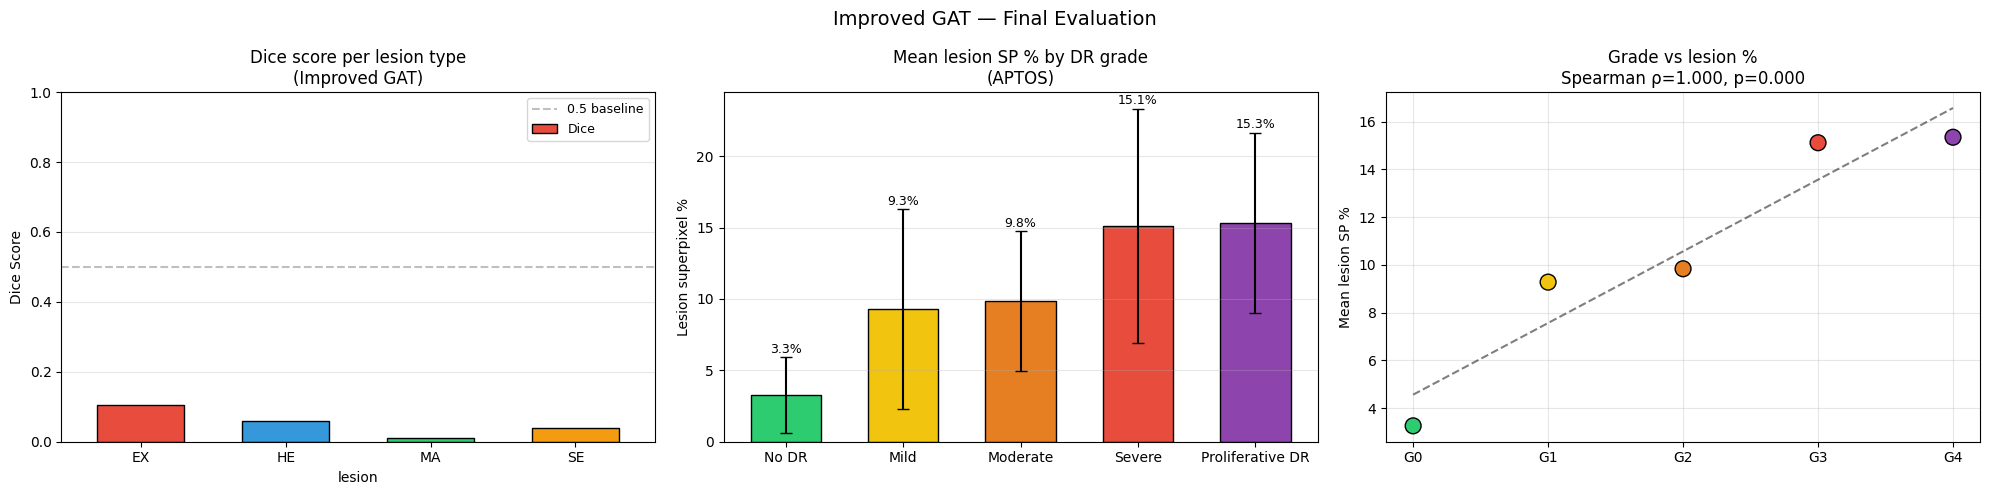


📋 Final Metric Table:
         Precision  Recall      F1     IoU    Dice
EX          0.0600  0.5943  0.1058  0.0586  0.1058
HE          0.0355  0.3661  0.0586  0.0313  0.0586
MA          0.0055  0.2833  0.0098  0.0049  0.0098
SE          0.0207  0.4234  0.0386  0.0201  0.0386
Overall     0.0319  0.4160  0.0553  0.0300  0.0553

Spearman ρ = 1.000  (p = 0.0000)


In [ ]:
# ── CELL 28: Final plots ─────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Dice per lesion type
colors_lesion = ["#e74c3c","#3498db","#2ecc71","#f39c12"]
per_lesion["Dice"].plot(kind="bar", ax=axes[0], color=colors_lesion,
                         edgecolor="black", width=0.6)
axes[0].set_title("Dice score per lesion type\n(Improved GAT)", fontsize=12)
axes[0].set_ylabel("Dice Score")
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 baseline')
axes[0].legend(fontsize=9)
axes[0].set_xticklabels(per_lesion.index, rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Grade-wise mean lesion %
colors_grade = ["#2ecc71","#f1c40f","#e67e22","#e74c3c","#8e44ad"]
lesion_pcts  = grade_results["mean_lesion_pct"]
lesion_std   = grade_results["std_lesion_pct"]
axes[1].bar(grade_results["grade_name"], lesion_pcts, yerr=lesion_std,
            color=colors_grade, edgecolor="black", capsize=4, width=0.6)
axes[1].set_title("Mean lesion SP % by DR grade\n(APTOS)", fontsize=12)
axes[1].set_ylabel("Lesion superpixel %")
axes[1].grid(axis='y', alpha=0.3)
for i, (v, s) in enumerate(zip(lesion_pcts, lesion_std)):
    axes[1].text(i, v + s + 0.3, f"{v:.1f}%", ha='center', fontsize=9)

# Plot 3: Spearman scatter
axes[2].scatter(grade_results["grade"], lesion_pcts,
                s=130, c=colors_grade, edgecolors="black", zorder=5)
z = np.polyfit(grade_results["grade"], lesion_pcts, 1)
x_line = np.linspace(0, 4, 100)
axes[2].plot(x_line, np.poly1d(z)(x_line), "k--", alpha=0.5, lw=1.5)
axes[2].set_xticks(range(5))
axes[2].set_xticklabels([f"G{g}" for g in range(5)])
axes[2].set_title(f"Grade vs lesion %\nSpearman ρ={corr:.3f}, p={pval:.3f}", fontsize=12)
axes[2].set_ylabel("Mean lesion SP %")
axes[2].grid(True, alpha=0.3)

plt.suptitle("Improved GAT — Final Evaluation", fontsize=14)
plt.tight_layout()
plt.show()

print("\n📋 Final Metric Table:")
print(summary[["Precision","Recall","F1","IoU","Dice"]].to_string())
print(f"\nSpearman ρ = {corr:.3f}  (p = {pval:.4f})")

In [ ]:
# ── CELL A: Diagnose class imbalance & model calibration ──
print("="*60)
print("DIAGNOSTIC: Class balance in your GT graphs")
print("="*60)
total_lesion, total_bg = 0, 0
for g in gt_graphs:
    n_les = (g.y == 1).sum().item()
    n_bg  = (g.y == 0).sum().item()
    total_lesion += n_les
    total_bg     += n_bg
    print(f"  {g.img_id:15s}  lesion={n_les:4d}  bg={n_bg:4d}  "
          f"ratio={n_bg/(n_les+1e-6):.1f}:1")

print(f"\nOverall  lesion={total_lesion}  bg={total_bg}  "
      f"ratio={total_bg/(total_lesion+1e-6):.1f}:1")
print("\nIf ratio > 20:1 → your model is just predicting background")

# Check if model is collapsed
print("\n" + "="*60)
print("DIAGNOSTIC: Probability distribution on first 3 images")
print("="*60)
gt_model.eval()
for g in gt_graphs[:3]:
    gg = g.to(DEVICE)
    with torch.no_grad():
        logits = gt_model(gg.x, gg.edge_index, gg.edge_attr)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
    print(f"  {g.img_id:15s}  min={probs.min():.4f}  max={probs.max():.4f}  "
          f"mean={probs.mean():.4f}  std={probs.std():.4f}")
    print(f"    → {'COLLAPSED (model predicts everything as BG)' if probs.std() < 0.02 else 'OK - has variation'}")

DIAGNOSTIC: Class balance in your GT graphs
  IDRiD_01         lesion=   2  bg= 134  ratio=67.0:1
  IDRiD_02         lesion=   2  bg= 137  ratio=68.5:1
  IDRiD_03         lesion=   8  bg= 127  ratio=15.9:1
  IDRiD_04         lesion=   1  bg= 139  ratio=139.0:1
  IDRiD_05         lesion=   0  bg= 135  ratio=135000000.0:1
  IDRiD_06         lesion=   0  bg= 138  ratio=138000000.0:1
  IDRiD_07         lesion=   3  bg= 132  ratio=44.0:1
  IDRiD_08         lesion=   1  bg= 135  ratio=135.0:1
  IDRiD_09         lesion=   4  bg= 132  ratio=33.0:1
  IDRiD_10         lesion=  15  bg= 118  ratio=7.9:1
  IDRiD_11         lesion=   4  bg= 132  ratio=33.0:1
  IDRiD_12         lesion=   1  bg= 140  ratio=140.0:1
  IDRiD_13         lesion=   5  bg= 125  ratio=25.0:1
  IDRiD_14         lesion=   1  bg= 132  ratio=132.0:1
  IDRiD_15         lesion=   0  bg= 134  ratio=134000000.0:1
  IDRiD_16         lesion=   1  bg= 135  ratio=135.0:1
  IDRiD_17         lesion=  33  bg= 105  ratio=3.2:1
  IDRiD_18    